In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix,
    classification_report, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer


Imports OK


In [2]:
# Chargement des données preprocessées
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# Tâche 1 — Classification
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')

# Tâche 2 — Régression
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

# Noms des features
feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f" Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")
print(f"   X_test  : {X_test.shape}")
print(f"   Churners dans test : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

 Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (rééquilibré 50/50)
   X_test          : (2000, 50)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)
   X_test  : (2000, 50)
   Churners dans test : 204 (10.2%)


## Tâche 1 — Classification du Churn


In [3]:
# TÂCHE 1 — CLASSIFICATION

# ---- Modèle 1 : Undersampling ----
# ============================================================
# TÂCHE 1 — CLASSIFICATION
# ============================================================

# Définition du modèle
lr_clf = LogisticRegression(
    max_iter=1000,            # Assure la convergence
    random_state=RANDOM_STATE
)

# Entraînement
# Entraînement sur les données rééquilibrées (undersampling)
lr_clf.fit(X_train_under, y_train_clf_under)

# Prédictions
y_pred_under  = lr_clf.predict(X_test)
y_proba_under = lr_clf.predict_proba(X_test)[:, 1]
y_pred_clf    = y_pred_under
y_proba_clf   = y_proba_under

print("Modèle entraîné !")
print(f"\n Résultats — Régression Logistique (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_under):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_under):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_under):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_under):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_under):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_under):.4f}")

print()

# ---- Modèle 2 : SMOTE ----
lr_clf_smote = lr_clf.__class__(**lr_clf.get_params())
lr_clf_smote.fit(X_train_smote, y_train_clf_smote)
y_pred_smote  = lr_clf_smote.predict(X_test)
y_proba_smote = lr_clf_smote.predict_proba(X_test)[:, 1]

print(f"=== Logistic Regression — SMOTE ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote):.4f}")

# Sélection du meilleur
recall_under = recall_score(y_test_clf, y_pred_under)
recall_smote = recall_score(y_test_clf, y_pred_smote)
if recall_smote >= recall_under:
    lr_clf = lr_clf_smote
    y_pred_clf  = y_pred_smote
    y_proba_clf = y_proba_smote
    best_technique = 'SMOTE'
else:
    best_technique = 'Undersampling'
print(f"\n→ Meilleure technique : {best_technique} (Recall={max(recall_under, recall_smote):.4f})")

Modèle entraîné !

 Résultats — Régression Logistique (Classification)
   Accuracy  : 0.6540
   Precision : 0.1738
   Recall    : 0.6373
   F1-Score  : 0.2731
   ROC-AUC   : 0.7090
   PR-AUC    : 0.2273

=== Logistic Regression — SMOTE ===
   Accuracy  : 0.6715
   Precision : 0.1823
   Recall    : 0.6373
   F1-Score  : 0.2835
   ROC-AUC   : 0.7120

→ Meilleure technique : SMOTE (Recall=0.6373)


## Approche niveau modèle — `class_weight='balanced'`

En complément du rééchantillonnage, on expérimente une approche au niveau du modèle : `class_weight='balanced'` pénalise davantage les erreurs sur la classe minoritaire (churners) en pondérant chaque classe inversement proportionnellement à sa fréquence.

**Avantage** : pas de modification des données, pas d'overfitting lié aux données synthétiques.  
**Limite** : peut réduire la précision sur la classe majoritaire.

On compare les 3 approches : Undersampling / SMOTE / class_weight='balanced'.

=== Logistic Regression — class_weight=balanced ===
   Accuracy  : 0.6685
   Precision : 0.1843
   Recall    : 0.6569
   F1-Score  : 0.2879
   ROC-AUC   : 0.7212
   PR-AUC    : 0.2385

=== Comparaison des 3 approches ===
Approche                    Recall  Precision       F1   ROC-AUC   PR-AUC
------------------------------------------------------------------------
Undersampling               0.6373     0.1738   0.2731    0.7090   0.2273
SMOTE                       0.6373     0.1823   0.2835    0.7120   0.2357
class_weight=balanced       0.6569     0.1843   0.2879    0.7212   0.2385


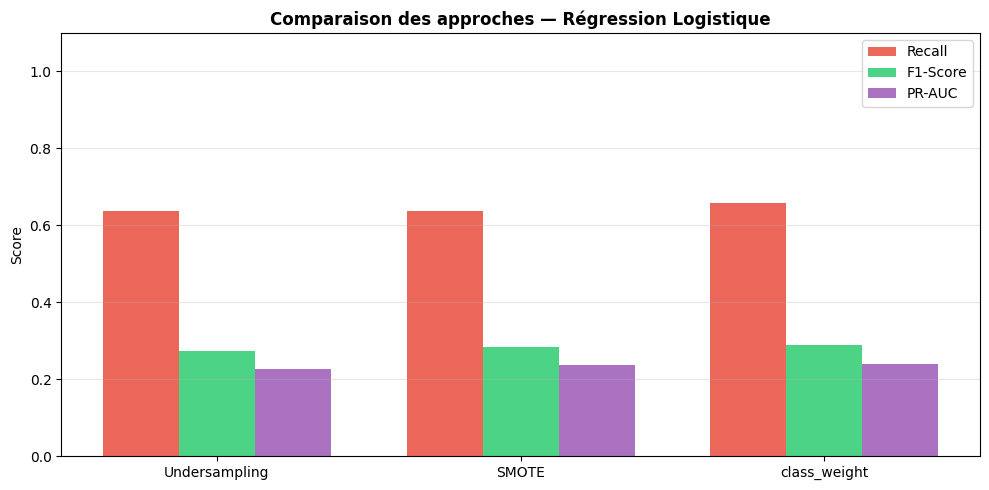

In [4]:
# APPROCHE NIVEAU MODÈLE — class_weight='balanced'

# Entraînement sur données originales (non rééquilibrées) avec class_weight
lr_clf_cw = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr_clf_cw.fit(X_train, y_train_clf)
y_pred_cw  = lr_clf_cw.predict(X_test)
y_proba_cw = lr_clf_cw.predict_proba(X_test)[:, 1]

print('=== Logistic Regression — class_weight=balanced ===')
print(f'   Accuracy  : {accuracy_score(y_test_clf, y_pred_cw):.4f}')
print(f'   Precision : {precision_score(y_test_clf, y_pred_cw):.4f}')
print(f'   Recall    : {recall_score(y_test_clf, y_pred_cw):.4f}')
print(f'   F1-Score  : {f1_score(y_test_clf, y_pred_cw):.4f}')
print(f'   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_cw):.4f}')
print(f'   PR-AUC    : {average_precision_score(y_test_clf, y_proba_cw):.4f}')

# Tableau comparatif des 3 approches
print('\n=== Comparaison des 3 approches ===')
header = f"{'Approche':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} {'ROC-AUC':>9} {'PR-AUC':>8}"
print(header)
print('-' * 72)
for name, y_pred, y_proba in [
    ('Undersampling',        y_pred_under, y_proba_under),
    ('SMOTE',                y_pred_smote, y_proba_smote),
    ('class_weight=balanced',y_pred_cw,    y_proba_cw),
]:
    print(f'{name:<25} '
          f'{recall_score(y_test_clf, y_pred):>8.4f} '
          f'{precision_score(y_test_clf, y_pred):>10.4f} '
          f'{f1_score(y_test_clf, y_pred):>8.4f} '
          f'{roc_auc_score(y_test_clf, y_proba):>9.4f} '
          f'{average_precision_score(y_test_clf, y_proba):>8.4f}')

# Visualisation comparative
approaches = ['Undersampling', 'SMOTE', 'class_weight']
recalls    = [recall_score(y_test_clf, y_pred_under), recall_score(y_test_clf, y_pred_smote), recall_score(y_test_clf, y_pred_cw)]
f1s        = [f1_score(y_test_clf, y_pred_under),     f1_score(y_test_clf, y_pred_smote),     f1_score(y_test_clf, y_pred_cw)]
pr_aucs    = [average_precision_score(y_test_clf, y_proba_under), average_precision_score(y_test_clf, y_proba_smote), average_precision_score(y_test_clf, y_proba_cw)]

x = np.arange(len(approaches))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, recalls, width, label='Recall',  color='#e74c3c', alpha=0.85)
ax.bar(x,         f1s,     width, label='F1-Score', color='#2ecc71', alpha=0.85)
ax.bar(x + width, pr_aucs, width, label='PR-AUC',  color='#9b59b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des approches — Régression Logistique', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/lr_approaches_comparison.png', dpi=150)
plt.show()


## Analyse des métriques



## Matrice de Confusion


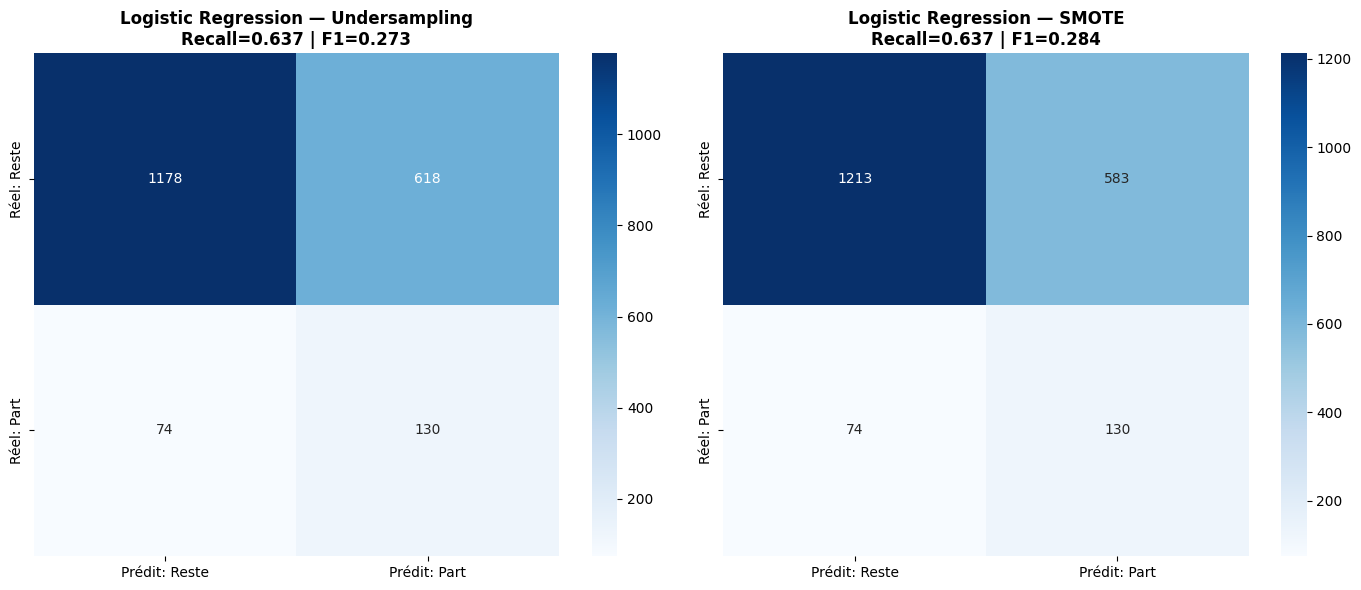


Meilleur modèle (SMOTE) :
   FN (churners manqués) : 74
   TP (churners détectés) : 130


In [5]:
# MATRICE DE CONFUSION — Comparaison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under, 'Logistic Regression — Undersampling', 'Blues'),
    (y_pred_smote, 'Logistic Regression — SMOTE', 'Blues'),
]):
    cm_plot = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/lr_confusion_matrix.png', dpi=150)
plt.show()

cm = confusion_matrix(y_test_clf, y_pred_clf)
tn, fp, fn, tp = cm.ravel()
print(f"\nMeilleur modèle ({best_technique}) :")
print(f"   FN (churners manqués) : {fn}")
print(f"   TP (churners détectés) : {tp}")

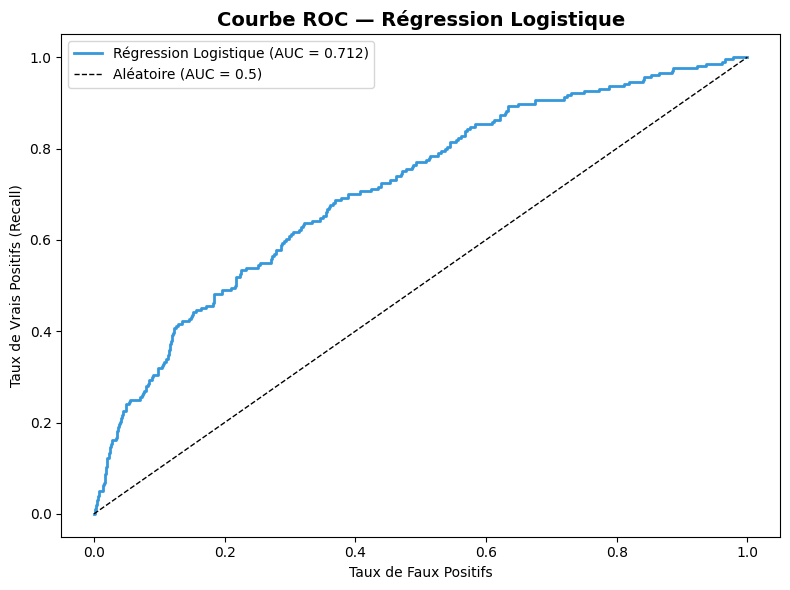

In [6]:
# COURBE ROC

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3498db', linewidth=2,
         label=f'Régression Logistique (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — Régression Logistique', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/lr_roc_curve.png', dpi=150)
plt.show()

## Ajustement du Seuil de Décision

Par défaut, un classifieur utilise un seuil de 0.5. Dans un contexte déséquilibré (10% de churners), ce seuil n'est pas optimal car il favorise la classe majoritaire.

On teste différents seuils et on mesure l'impact sur :
- **Recall** : taux de churners détectés (minimiser les FN)
- **Precision** : taux de vrais churners parmi les alertes (minimiser les FP)
- **F1-Score** : compromis precision/recall
- **FP / FN** : impact métier direct

Seuil par défaut (0.5) :
  Recall=0.637 | Precision=0.182 | F1=0.284 | FP=583 | FN=74

Seuil optimal (0.65) :
  Recall=0.441 | Precision=0.243 | F1=0.314 | FP=280 | FN=114


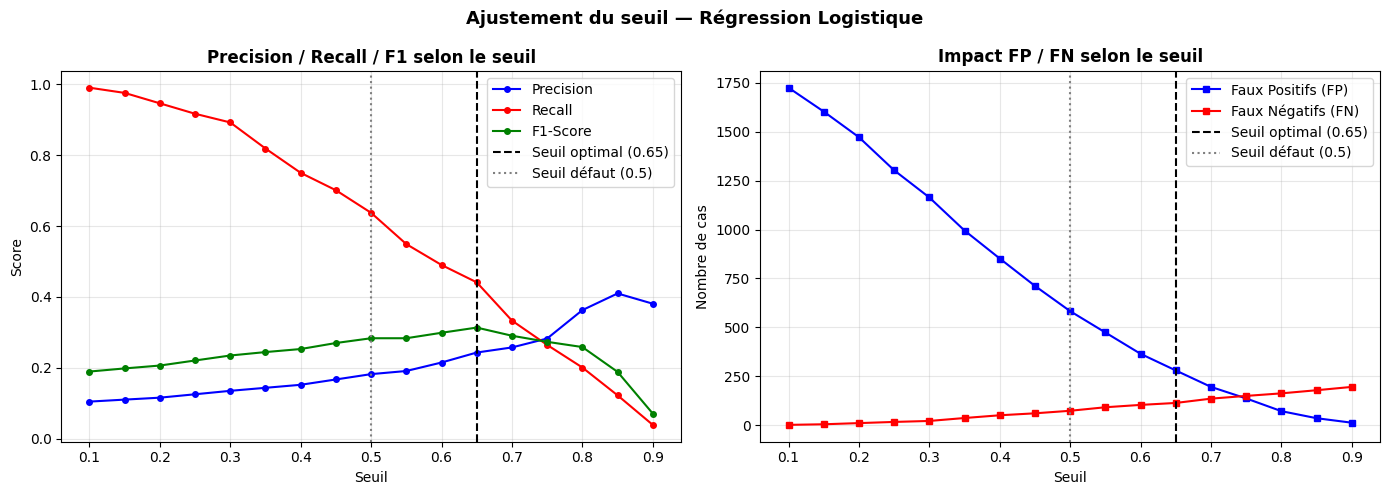

 seuil  precision   recall       f1   FP  FN  TP
  0.10   0.104826 0.990196 0.189582 1725   2 202
  0.15   0.110433 0.975490 0.198405 1603   5 199
  0.20   0.115916 0.946078 0.206528 1472  11 193
  0.25   0.125503 0.916667 0.220779 1303  17 187
  0.30   0.135215 0.892157 0.234839 1164  22 182
  0.35   0.143718 0.818627 0.244510  995  37 167
  0.40   0.152239 0.750000 0.253102  852  51 153
  0.45   0.167251 0.700980 0.270066  712  61 143
  0.50   0.182328 0.637255 0.283533  583  74 130
  0.55   0.191126 0.549020 0.283544  474  92 112
  0.60   0.215054 0.490196 0.298954  365 104 100
  0.65   0.243243 0.441176 0.313589  280 114  90
  0.70   0.257576 0.333333 0.290598  196 136  68
  0.75   0.282723 0.264706 0.273418  137 150  54
  0.80   0.362832 0.200980 0.258675   72 163  41
  0.85   0.409836 0.122549 0.188679   36 179  25
  0.90   0.380952 0.039216 0.071111   13 196   8

Prédictions mises à jour avec seuil=0.65
  Recall final  : 0.4412
  F1 final      : 0.3136


In [7]:
# AJUSTEMENT DU SEUIL DE DÉCISION

thresholds = np.arange(0.1, 0.91, 0.05)

results_thresh = []
for t in thresholds:
    y_pred_t = (y_proba_clf >= t).astype(int)
    cm_t = confusion_matrix(y_test_clf, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results_thresh.append({
        'seuil':     round(t, 2),
        'precision': precision_score(y_test_clf, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test_clf, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test_clf, y_pred_t, zero_division=0),
        'FP':        int(fp_t),
        'FN':        int(fn_t),
        'TP':        int(tp_t),
    })

df_thresh = pd.DataFrame(results_thresh)

# Seuil optimal = max F1
best_idx = df_thresh['f1'].idxmax()
best_t   = df_thresh.loc[best_idx, 'seuil']

# Affichage comparaison seuil 0.5 vs optimal
rows_05 = df_thresh[df_thresh['seuil'] == 0.5]
if len(rows_05) > 0:
    r05 = rows_05.iloc[0]
    print(f"Seuil par défaut (0.5) :")
    print(f"  Recall={r05['recall']:.3f} | Precision={r05['precision']:.3f} | F1={r05['f1']:.3f} | FP={int(r05['FP'])} | FN={int(r05['FN'])}")

br = df_thresh.loc[best_idx]
print(f"\nSeuil optimal ({best_t}) :")
print(f"  Recall={br['recall']:.3f} | Precision={br['precision']:.3f} | F1={br['f1']:.3f} | FP={int(br['FP'])} | FN={int(br['FN'])}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh['seuil'], df_thresh['precision'], 'b-o', markersize=4, label='Precision')
axes[0].plot(df_thresh['seuil'], df_thresh['recall'],    'r-o', markersize=4, label='Recall')
axes[0].plot(df_thresh['seuil'], df_thresh['f1'],        'g-o', markersize=4, label='F1-Score')
axes[0].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil optimal ({best_t})')
axes[0].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 selon le seuil', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_thresh['seuil'], df_thresh['FP'], 'b-s', markersize=4, label='Faux Positifs (FP)')
axes[1].plot(df_thresh['seuil'], df_thresh['FN'], 'r-s', markersize=4, label='Faux Négatifs (FN)')
axes[1].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil optimal ({best_t})')
axes[1].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('Nombre de cas')
axes[1].set_title('Impact FP / FN selon le seuil', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Ajustement du seuil — Régression Logistique', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/lr_threshold_analysis.png', dpi=150)
plt.show()

print(df_thresh.to_string(index=False))

# Mise à jour des prédictions finales avec le seuil optimal
y_pred_clf = (y_proba_clf >= best_t).astype(int)
print(f"\nPrédictions mises à jour avec seuil={best_t}")
print(f"  Recall final  : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"  F1 final      : {f1_score(y_test_clf, y_pred_clf):.4f}")


## Validation Croisée Stratifiée (Stratified K-Fold)

Un simple split train/test peut être sensible au hasard de la partition. La validation croisée stratifiée permet d'obtenir une estimation plus robuste des performances en préservant les proportions de classes (10% churners) dans chaque fold.

**Pourquoi stratifiée ?**  
Avec seulement 10% de churners, un fold non stratifié pourrait se retrouver avec très peu (ou aucun) churner, rendant les métriques instables.

On évalue le meilleur modèle (issu de la comparaison Undersampling vs SMOTE) sur 5 folds stratifiés et on reporte mean ± std pour chaque métrique.

Stratified K-Fold (5 folds) — Régression Logistique
--------------------------------------------------
  recall       : 0.6377 ± 0.0307
  precision    : 0.1836 ± 0.0122
  f1           : 0.2851 ± 0.0177
  roc_auc      : nan ± nan
  pr_auc       : nan ± nan

Comparaison avec le score test set (seuil optimisé) :
  recall     : 0.4412  (test set)
  f1         : 0.3136  (test set)
  roc_auc    : 0.7120  (test set)
  pr_auc     : 0.2357  (test set)


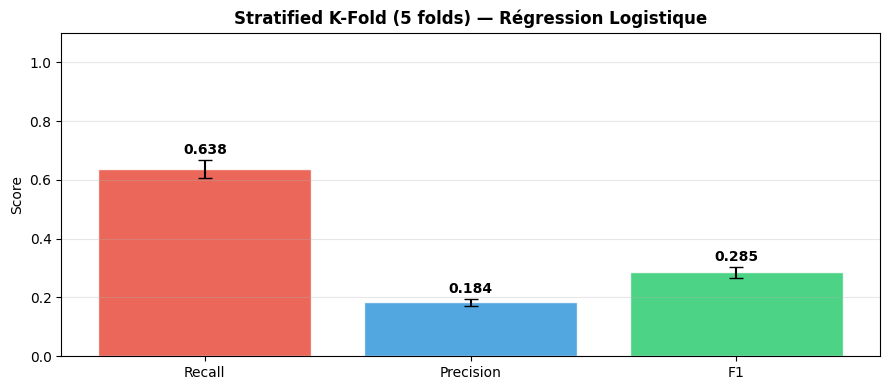

In [8]:
# VALIDATION CROISÉE STRATIFIÉE — Stratified K-Fold

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall':    make_scorer(recall_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'f1':        make_scorer(f1_score),
    'roc_auc':   make_scorer(roc_auc_score, needs_proba=True),
    'pr_auc':    make_scorer(average_precision_score, needs_proba=True),
}

# Pipeline : rééquilibrage SMOTE à l'intérieur du fold (évite le data leakage)
pipe = ImbPipeline([
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('clf',     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

cv_results = cross_validate(
    pipe,
    X_train, y_train_clf,
    cv=skf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print(f'Stratified K-Fold ({N_SPLITS} folds) — Régression Logistique')
print('-' * 50)
for metric in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']:
    scores = cv_results[f'test_{metric}']
    print(f'  {metric:12} : {scores.mean():.4f} ± {scores.std():.4f}')

# Comparaison avec le score sur le test set
print('\nComparaison avec le score test set (seuil optimisé) :')
print(f'  recall     : {recall_score(y_test_clf, y_pred_clf):.4f}  (test set)')
print(f'  f1         : {f1_score(y_test_clf, y_pred_clf):.4f}  (test set)')
print(f'  roc_auc    : {roc_auc_score(y_test_clf, y_proba_clf):.4f}  (test set)')
print(f'  pr_auc     : {average_precision_score(y_test_clf, y_proba_clf):.4f}  (test set)')

# Visualisation mean ± std
metrics_labels = ['Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']
metrics_keys   = ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']
means = [cv_results[f'test_{k}'].mean() for k in metrics_keys]
stds  = [cv_results[f'test_{k}'].std()  for k in metrics_keys]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics_labels, means, yerr=stds, capsize=5,
              color=['#e74c3c','#3498db','#2ecc71','#9b59b6','#e67e22'],
              edgecolor='white', alpha=0.85)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Stratified K-Fold (5 folds) — Régression Logistique', fontweight='bold')
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.02,
            f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/lr_kfold_cv.png', dpi=150)
plt.show()


## Tâche 2 — Régression du Revenu à Risque


In [9]:
# ============================================================
# TÂCHE 2 — RÉGRESSION (Ridge baseline)
# ============================================================

# Charger les données spécifiques régression
X_train_reg     = np.load('../data/processed/X_train_reg.npy')       # churners uniquement
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')   # log-transformé
y_test_reg      = np.load('../data/processed/y_test_reg.npy')        # valeurs réelles €

lr_reg = Ridge(alpha=1.0, random_state=RANDOM_STATE)

# Entraînement sur churners uniquement avec y log-transformé
lr_reg.fit(X_train_reg, y_train_reg_log)

# Prédiction sur TOUS les clients du test
y_pred_reg_log = lr_reg.predict(X_test)

# Transformation inverse log → euros réels
y_pred_reg = np.expm1(y_pred_reg_log)
y_pred_reg = np.maximum(y_pred_reg, 0)  # pas de valeurs négatives

# Évaluation sur les churners du test uniquement
churners_test_mask = y_test_reg > 0
mae  = mean_absolute_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])
rmse = np.sqrt(mean_squared_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask]))
r2   = r2_score(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])

print("Modèle de régression entraîné !")
print(f"\nRésultats — Ridge Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Modèle de régression entraîné !

Résultats — Ridge Regression (churners uniquement)
   MAE  : 330.91 €
   RMSE : 724.96 €
   R²   : 0.4183


In [10]:
# SAUVEGARDE DES MODÈLES ET RÉSULTATS

# Sauvegarde des modèles
print(f'Sauvegarde du meilleur modèle : {best_technique}')
joblib.dump(lr_clf, '../models/lr_classification.pkl')
joblib.dump(lr_reg, '../models/lr_regression.pkl')

# Sauvegarde des résultats pour la comparaison finale
results_clf = {
    'model': 'Logistic Regression (' + best_technique + ')',
    'accuracy':  accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall':    recall_score(y_test_clf, y_pred_clf),
    'f1':        f1_score(y_test_clf, y_pred_clf),
    'roc_auc':   roc_auc_score(y_test_clf, y_proba_clf),
    'pr_auc':    average_precision_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'Ridge Regression',
    'mae':  mae,
    'rmse': rmse,
    'r2':   r2
}

pd.DataFrame([results_clf]).to_csv('../results/lr_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/lr_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\nRésumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Sauvegarde du meilleur modèle : SMOTE
Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

Résumé Classification :
   accuracy   : 0.8030
   precision  : 0.2432
   recall     : 0.4412
   f1         : 0.3136
   roc_auc    : 0.7120
   pr_auc     : 0.2357


## Synthèse — Régression Logistique (Baseline)
